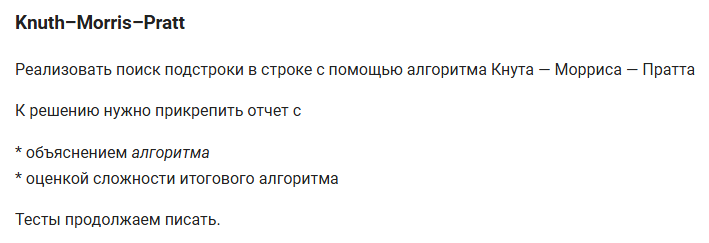

### Объяснение алгоритма Кнута - Морриса - Пратта

#### Проблема наивного подхода:
При обычном поиске подстроки, если мы находим несовпадение символов, мы сдвигаем шаблон (подстроку) всего на один символ вправо и начинаем сравнение заново. Это приводит к лишним сравнениям, и в худшем случае сложность составляет O(N * M).

#### Идея КМП:
Алгоритм использует информацию о том, что при несовпадении мы уже знаем, какие символы предшествовали этому месту в тексте (так как они совпадали с частью шаблона). Это позволяет сдвигать шаблон не на 1 позицию, а на максимально возможное безопасное расстояние, не теряя потенциального совпадения.

#### Префикс-функция:
Ключевой элемент алгоритма - предварительный расчет массива $\pi$ (lps - Longest Prefix Suffix).
Для каждой позиции i в шаблоне значение $\pi[i]$ равно длине самого длинного собственного префикса подстроки Pattern[0...i], который одновременно является её суффиксом.

#### Процесс поиска:
1. Идём по тексту слева направо.
2. Если символы совпадают, двигаем указатели и текста, и шаблона.
3. Если произошло несовпадение после нескольких удачных сравнений, мы не сбрасываем указатель текста назад. Вместо этого мы используем массив lps, чтобы передвинуть указатель шаблона на позицию lps[предыдущий_индекс]. Это позволяет пропустить уже проверенные части, которые гарантированно совпадают.

### Оценка сложности

Пусть N - длина текста, а M - длина шаблона (подстроки).

##### Временная сложность:
* Препроцессинг (расчет префикс-функции): Проходим по шаблону один раз. Сложность: O(M).
* Поиск: Проходим по тексту один раз. Указатель текста никогда не двигается назад. Указатель шаблона может двигаться назад, но суммарное количество таких движений не превышает длины текста. Сложность: O(N).
* Итоговая сложность: O(N + M). Это значительно быстрее наивного алгоритма O(N * M), особенно для длинных текстов и шаблонов с повторяющимися частями.

##### Пространственная сложность:
* Требуется O(M) дополнительной памяти для хранения массива префикс-функции (lps).

In [1]:
# Вычисление префикс функции
def compute_lps_array(pattern):
    
    m = len(pattern)
    lps = [0] * m
    length = 0
    i = 1

    while i < m:
        if pattern[i] == pattern[length]:
            length += 1
            lps[i] = length
            i += 1
        else:
            if length != 0:
                length = lps[length - 1]
            else:
                lps[i] = 0
                i += 1
    return lps


# Поиск всех вхождений патерна в текст
def kmp_search(text, pattern):
   
    n = len(text)
    m = len(pattern)
    
    if m == 0:
        return []
    if m > n:
        return []

    lps = compute_lps_array(pattern)
    results = []
    
    i = 0
    j = 0

    while i < n:
        if pattern[j] == text[i]:
            i += 1
            j += 1

        if j == m:
            # Найдено полное совпадение
            results.append(i - j)
            j = lps[j - 1]
        
        # Несовпадение после j совпадений
        elif i < n and pattern[j] != text[i]:
            if j != 0:
                # Используем lps массив для сдвига j
                j = lps[j - 1]
            else:
                # Если j=0, переходим к следующему символу текста
                i += 1
                
    return results

In [2]:
# Тесты
if __name__ == "__main__":
    
    # Обычный поиск одного вхождения
    text = "hello world"
    pattern = "world"
    kmp = kmp_search(text, pattern)
    print(kmp)  # [6]

    # Совпадение в самом начале
    text = "hello world"
    pattern = "hello"
    kmp = kmp_search(text, pattern)
    print(kmp)  # [0]

    # Несколько вхождений
    text = "ababa"
    pattern = "aba"
    kmp = kmp_search(text, pattern)
    print(kmp)  # [0, 2]

    # Отсутствие вхождения
    text = "abcde"
    pattern = "xyz"
    kmp = kmp_search(text, pattern)
    print(kmp)  # []

    # Паттерн длиннее текста
    text = "short"
    pattern = "very long pattern"
    kmp = kmp_search(text, pattern)
    print(kmp)  # []

    # Пустой паттерн (по логике можно возвращать [], либо считать ошибкой)
    text = "something"
    pattern = ""
    kmp = kmp_search(text, pattern)
    print(kmp)  # []

    # Паттерн равен тексту
    text = "exactmatch"
    pattern = "exactmatch"
    kmp = kmp_search(text, pattern)
    print(kmp)  # [0]
    
    # Работа с Unicode/Кириллицей
    text = "Привет, мир! Привет всем!"
    pattern = "Привет"
    kmp = kmp_search(text, pattern)
    print(kmp)  # [0, 13]

[6]
[0]
[0, 2]
[]
[]
[]
[0]
[0, 13]
